In [43]:
%%time
import sys
print(sys.version)
print(sys.executable)

import pandas as pd
import requests
import missingno as msno
from io import StringIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

# Global visual style for the project
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,
    "axes.linewidth": 0.8,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.labelcolor": "#333333",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "grid.color": "#D9D9D9",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.7,
    "font.size": 10,
    "font.family": "DejaVu Sans",
    "legend.frameon": False
})

3.12.10 (v3.12.10:0cc81280367, Apr  8 2025, 08:46:59) [Clang 13.0.0 (clang-1300.0.29.30)]
/Users/deenuy/Documents/Workspace/Pet-projects/python_repos/agentic-ai-workspace/cangov-contracts-data-web/venv/bin/python
CPU times: user 260 μs, sys: 863 μs, total: 1.12 ms
Wall time: 671 μs


In [121]:
# Helper functions
def fmt_label_dollars(x):
    if x >= 1_000_000_000:
        return f"${x/1_000_000_000:.2f}B"
    if x >= 1_000_000:
        return f"${x/1_000_000:.2f}M"
    if x >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:,.0f}"

PRIMARY = "#1f4e79"
ACCENT = "#c75b39"
TEXT = "#1f1f1f"
SUBTLE = "#6b7280"
GRID = "#d9dde3"
BG = "white"

def label_money_short(x):
    if x >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if x >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:,.0f}"

def plot_compact_percentiles(values, labels, title, subtitle, figsize=(8, 4.8)):
    import numpy as np
    import matplotlib.pyplot as plt

    values = np.array(values, dtype=float)
    y = np.arange(len(labels))

    # Optional: shorten long labels
    def shorten(x, max_len=26):
        x = str(x)
        return x if len(x) <= max_len else x[:max_len] + "..."

    labels = [shorten(lbl) for lbl in labels]

    # Figure
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    colors = [PRIMARY] * len(values)
    colors[-1] = ACCENT

    # Stems + dots
    ax.hlines(y, xmin=values.min() * 0.9, xmax=values, color=GRID, linewidth=1.6)
    ax.scatter(values, y, s=45, color=colors, zorder=3)

    # Log scale
    ax.set_xscale("log")

    # Value labels
    for i, (v, yi) in enumerate(zip(values, y)):
        ax.text(
            v * 1.08,
            yi,
            label_money_short(v),
            va="center",
            ha="left",
            fontsize=8,
            color=TEXT,
            fontweight="bold" if i >= 4 else "normal"
        )

    # Y-axis labels
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8, color=TEXT)
    ax.invert_yaxis()

    # X-axis labels
    ax.set_xticks([10_000, 100_000, 1_000_000, 10_000_000])
    ax.set_xticklabels(["$10K", "$100K", "$1M", "$10M"], fontsize=8, color=SUBTLE)

    # Axis styling
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GRID)

    ax.tick_params(axis="y", length=0, labelsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="x", color=GRID, linewidth=0.8)

    # Titles
    fig.text(
        0.08, 0.96, title,
        ha="left", va="top",
        fontsize=11, fontweight="bold", color=TEXT
    )
    fig.text(
        0.08, 0.915, subtitle,
        ha="left", va="top",
        fontsize=8, color=SUBTLE
    )

    plt.tight_layout(rect=[0.06, 0.08, 0.98, 0.84])
    plt.show()

## Download Data from Government of Canada Open Data Portal

In [ ]:
# ============================================================
#  Download Data from Government of Canada Open Data Portal
# Run this cell ONLY once (or when refreshing source data)
# ============================================================

# # URL of the dataset
# url = "https://search.open.canada.ca/cache/search_contracts_a0d8aed526bfbabafc061fef38941f6bcd7a8d9d_en.csv"
#
# # Step 1: Download the file
# response = requests.get(url)
# response.raise_for_status()  # ensures we fail fast if something breaks
#
# # Step 2: Load into pandas
# csv_data = StringIO(response.text)
# df = pd.read_csv(csv_data, encoding="latin1", low_memory=False)
#
# # (Optional but recommended) Save locally for future runs
# df.to_csv("data/contracts_above_10k.csv", index=False)

## Import Government Contracts Dataset ('/data/contracts_above_10k.csv')

In [20]:
# ============================================================
# Load data from Government Contracts Dataset ('/data/contracts_above_10k.csv')
# Run this cell for all regular analysis
# ============================================================

# Load local file
df = pd.read_csv("data/contracts_above_10k.csv", encoding="latin1", low_memory=False)


# ============================================================
# CLEAN COLUMN NAMES
# Fix BOM issues, remove quotes, standardize formatting
# ============================================================

# Clean column names (fix BOM + spaces)
df.columns = df.columns.str.replace('ï»¿"', '', regex=False) \
    .str.replace('"', '', regex=False) \
    .str.lower().str.strip().str.replace(" ", "_")

# Clean column names
df.columns = (
    df.columns
    .str.replace('ï»¿"', '', regex=False)
    .str.replace('"', '', regex=False)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


# ============================================================
# QUICK SANITY CHECK
# ============================================================

print("\n")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\n")


# ============================================================
# PREVIEW DATA
# ============================================================

df.head(10)



Shape: (1261332, 48)
Columns: ['reference_number', 'procurement_identification_number', 'vendor_name', 'vendor_postal_code', 'buyer_name', 'contract_date', 'contract_year', 'economic_object_code', 'description_of_work_english', 'contract_period_start_date', 'contract_period_end_date_or_delivery_date', 'total_contract_value', 'original_contract_value', 'contract_amendment_value', 'comments_english', 'additional_comments_english', 'agreement_type', 'commodity', 'commodity_code', 'country_of_vendor', 'solicitation_procedure', 'limited_tendering_reason', 'trade_agreement_exceptions', 'indigenous_business_excluding_psib_(formerly_psab_incidental_indicator)', 'intellectual_property', 'potential_for_commercial_exploitation', 'former_public_servant', 'standing_offer_or_supply_arrangement_number', 'instrument_type', "minister's_office_contracts", 'number_of_bids', 'reporting_period', 'organization', 'amendment_no.', 'procurement_count', 'aggregate_total', 'working_procurement_id', 'total_cont

,reference_number,procurement_identification_number,vendor_name,vendor_postal_code,buyer_name,contract_date,contract_year,economic_object_code,description_of_work_english,contract_period_start_date,...,trade_agreements,socio-economic_indicator,section_6_government_contracts_regulations_exceptions,procurement_strategy_for_indigenous_business,original_contract_value.1,amendment_value,award_criteria,standing_offer,comprehensive_land_claims_agreement,id
0,C-2011-2012-Q2-01000,3000443700,GOWLING WLG [CANADA] LLP,K1P,"Collinge, Colby",2011-07-18T00:00:00Z,2011,410,Legal services,2011-07-18T00:00:00Z,...,Canadian Free Trade Agreement,Federal Contractors Program for Employment Equity,Not applicable,1. None,-,-,Highest Combined Rating of Technical Merit and...,Contract awarded by the department.,Not Applicable,"aafc-aac,C-2011-2012-Q2-01000"
1,C-2013-2014-Q4-01000,20140626A,PITNEY BOWES LEASING,-,-,2014-01-30T00:00:00Z,2014,1239,Other office equipment and Parts,2014-01-30T00:00:00Z,...,NaN,-,-,-,-,-,-,-,-,"aafc-aac,C-2013-2014-Q4-01000"
2,C-2013-2014-Q4-01001,20140596A,WORKDYNAMICS TECHNOLOGIES INC.,-,-,2014-01-17T00:00:00Z,2014,583,License/Maintenance fees for application softw...,2014-01-17T00:00:00Z,...,"Agreement on Internal Trade (AIT),North Americ...",-,-,-,-,-,-,-,-,"aafc-aac,C-2013-2014-Q4-01001"
3,C-2014-2015-Q1-00362,7200001447,DALIAN ENTERPRISES AND CORADIX TECHNOLOGIES CO...,K1P,Desta Kissack,2014-04-03T00:00:00Z,2014,473,Information technology and telecommunications ...,2014-04-03T00:00:00Z,...,"Canada-Chile Free Trade Agreement (CCFTA),Cana...",NaN,-,1. None,-,-,-,Call-up or Contract Against a Standing Offer o...,-,"aafc-aac,C-2014-2015-Q1-00362"
4,C-2014-2015-Q1-01000,3000549710,TELUS HEALTH (CANADA) LTD.,M4Y,",",2014-06-01T00:00:00Z,2014,491,Management consulting,2014-06-01T00:00:00Z,...,"Agreement on Internal Trade (AIT),Canada-Chile...",-,-,-,-,-,-,-,Not Applicable,"aafc-aac,C-2014-2015-Q1-01000"
5,C-2014-2015-Q2-01000,3000557991,MOFFAT & CO,K1Y,",",2014-09-22T00:00:00Z,2014,410,Legal services,2014-09-22T00:00:00Z,...,"Agreement on Internal Trade (AIT),Canada-Chile...",-,-,-,-,-,-,Call-up or Contract Against a Standing Offer o...,Not Applicable,"aafc-aac,C-2014-2015-Q2-01000"
6,C-2014-2015-Q3-01000,20140124A,XEROX CANADA,-,-,2014-11-17T00:00:00Z,2014,321,Printing services,2014-11-17T00:00:00Z,...,NaN,-,-,-,-,-,-,Contract awarded by PSPC on behalf of the clie...,-,"aafc-aac,C-2014-2015-Q3-01000"
7,C-2014-2015-Q3-01001,7200000722,IBM CANADA LTD,-,-,2014-11-24T00:00:00Z,2014,473,Information technology and telecommunications ...,2014-11-24T00:00:00Z,...,NaN,-,-,-,-,-,-,Call-up or Contract Against a Standing Offer o...,-,"aafc-aac,C-2014-2015-Q3-01001"
8,C-2014-2015-Q3-01002,3000559704,CONTROLS & EQUIPMENT LTD.,E1E,",",2014-10-01T00:00:00Z,2014,1245,Safety and sanitation equipment and parts,2014-10-01T00:00:00Z,...,NaN,-,-,-,-,-,-,-,Not Applicable,"aafc-aac,C-2014-2015-Q3-01002"
9,C-2014-2015-Q3-01003,3000563359,PRIORITY MANAGEMENT,K1Y,",",2014-12-08T00:00:00Z,2014,448,Purchase of training packages and courses,2014-12-08T00:00:00Z,...,"Agreement on Internal Trade (AIT),Canada-Chile...",-,-,-,-,-,-,-,Not Applicable,"aafc-aac,C-2014-2015-Q3-01003"


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1261332 entries, 0 to 1261331
Data columns (total 48 columns):
 #   Column                                                                   Non-Null Count    Dtype  
---  ------                                                                   --------------    -----  
 0   reference_number                                                         1261330 non-null  object 
 1   procurement_identification_number                                        1260965 non-null  object 
 2   vendor_name                                                              1261144 non-null  object 
 3   vendor_postal_code                                                       1208395 non-null  object 
 4   buyer_name                                                               1157491 non-null  object 
 5   contract_date                                                            1261332 non-null  object 
 6   contract_year                                     


Missing values by column:



<Axes: >

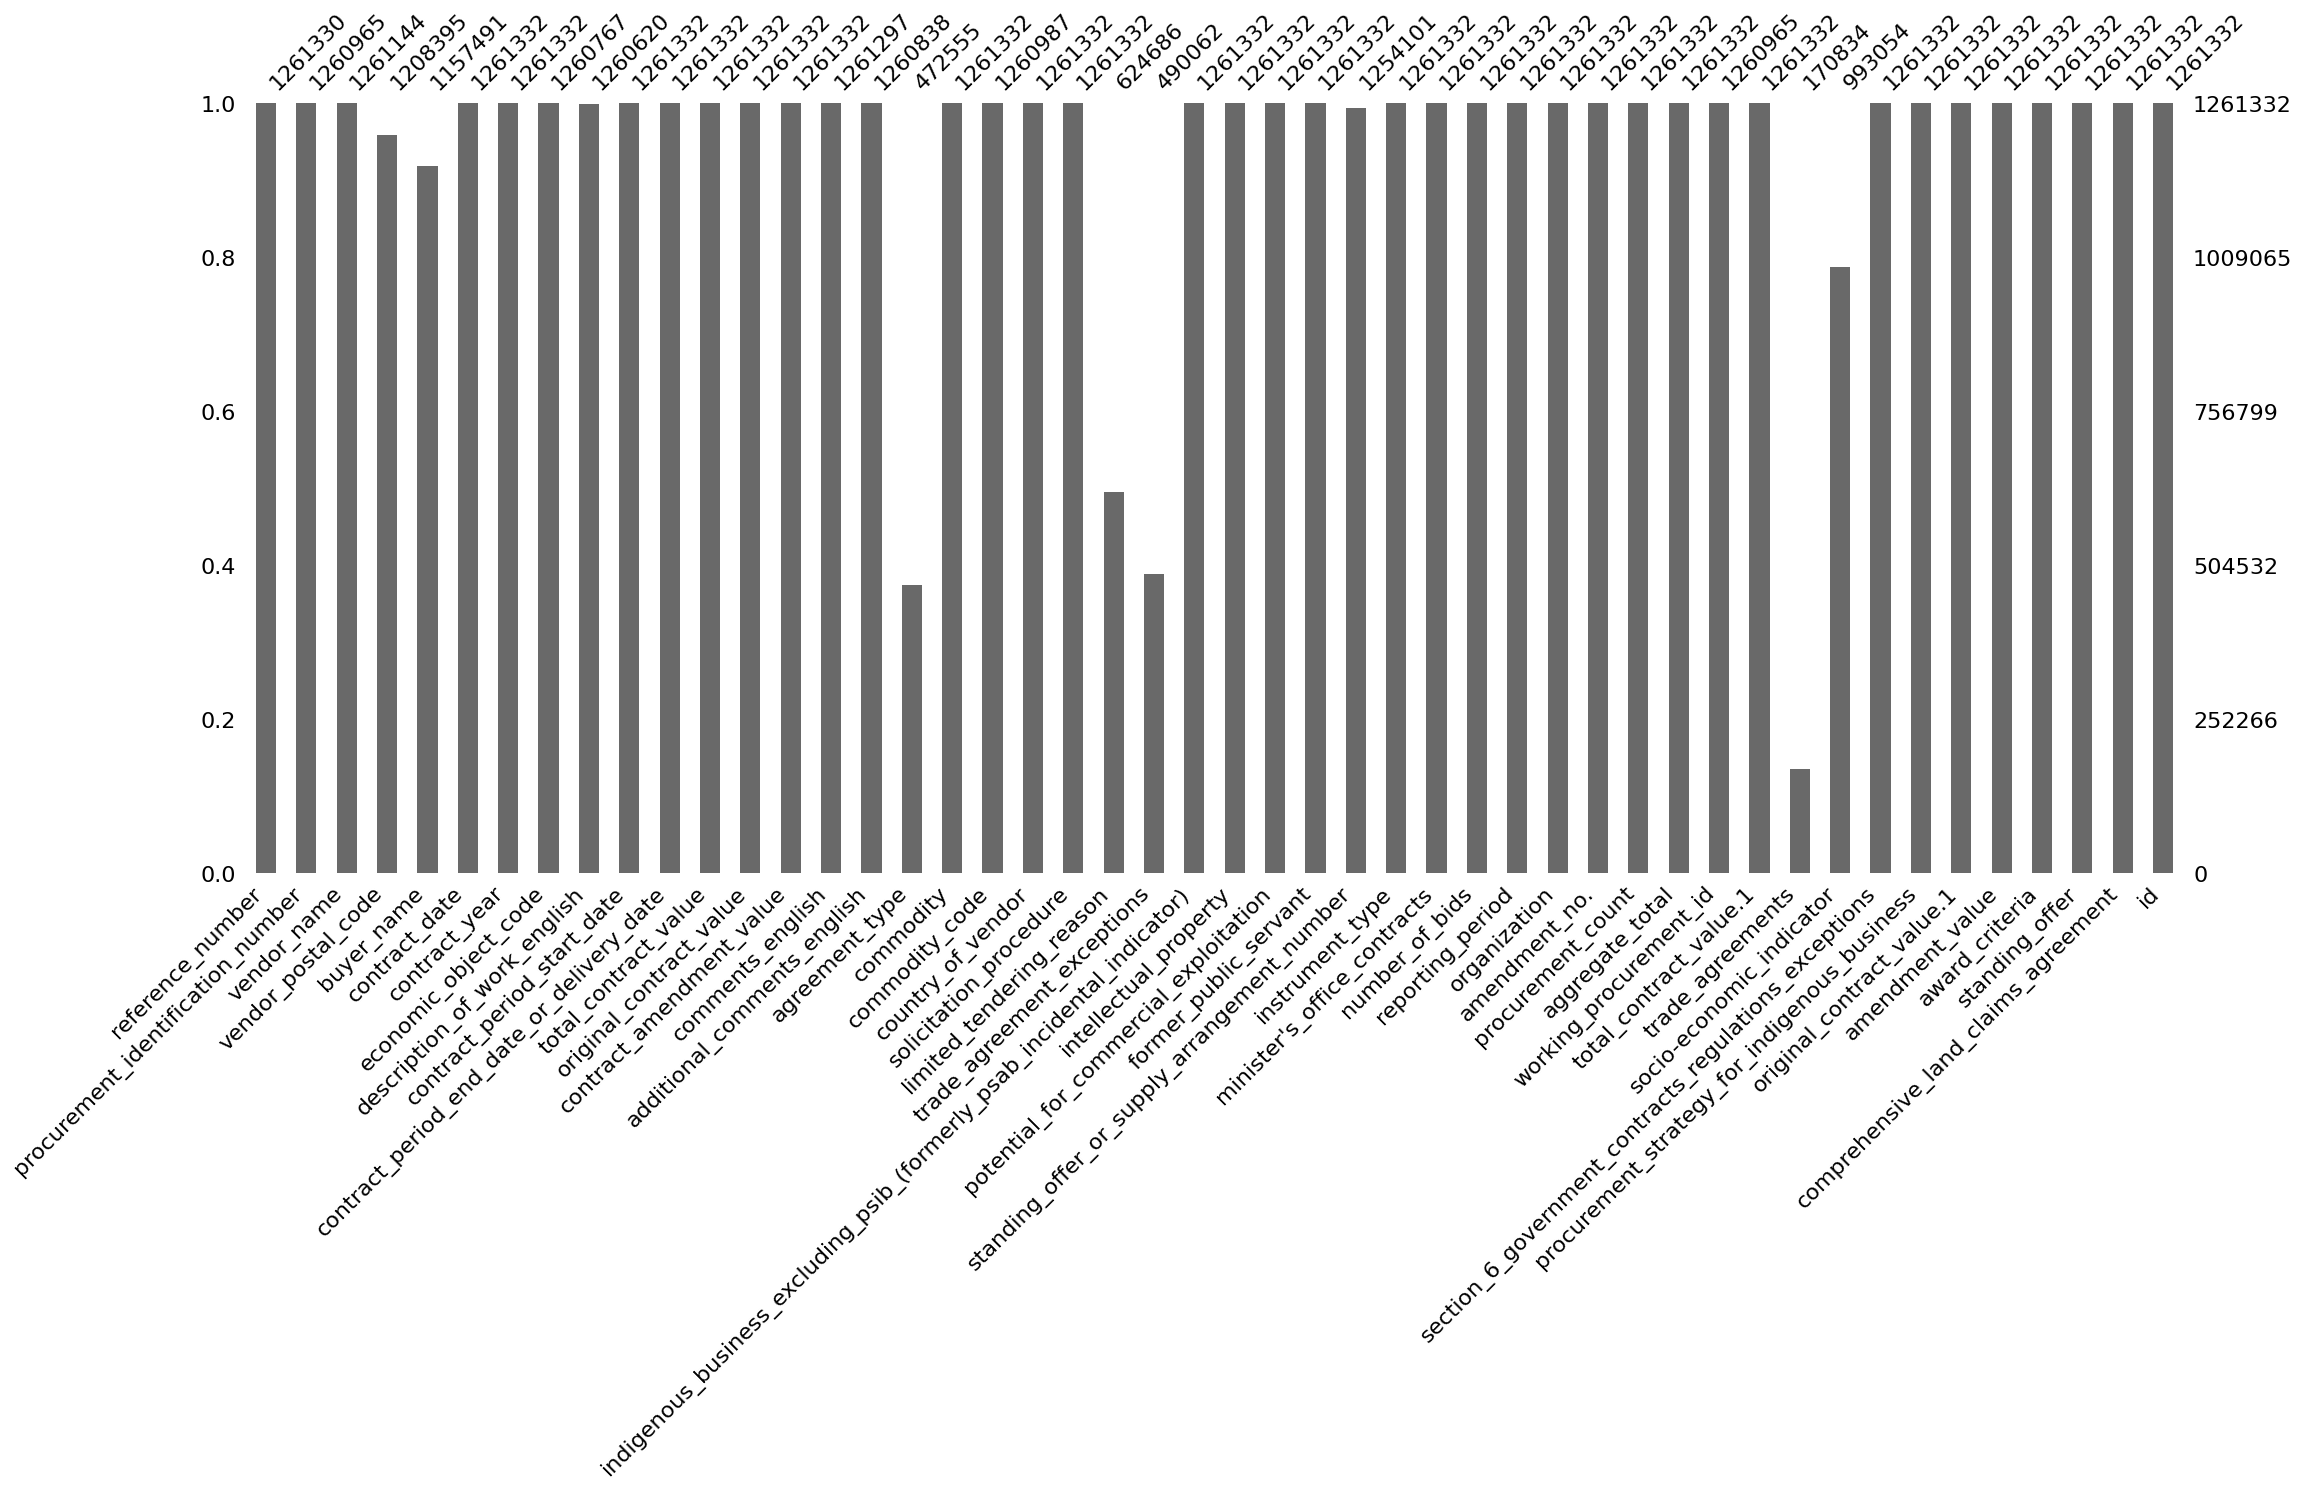

In [9]:
print("\nMissing values by column:\n")
msno.bar(df)

In [10]:
import pandas as pd

# Convert key fields
df['contract_date'] = pd.to_datetime(df['contract_date'], errors='coerce')
df['total_contract_value'] = pd.to_numeric(df['total_contract_value'], errors='coerce')

# Drop obvious nulls
df = df.dropna(subset=['total_contract_value', 'country_of_vendor'])

# Describe
summary = df['total_contract_value'].describe()

summary_df = pd.DataFrame({
    "Metric": summary.index,
    "Readable": summary.apply(lambda x: f"${x:,.0f}").values
})

print("\n=== Contract Value Summary (All Data) ===\n")
display(summary_df)


=== Contract Value Summary (All Data) ===



,Metric,Readable
0,count,"$1,261,332"
1,mean,"$863,545"
2,std,"$36,078,228"
3,min,"$-8,164,034"
4,25%,"$16,127"
5,50%,"$28,166"
6,75%,"$90,464"
7,max,"$20,027,318,000"


In [13]:
print("\n=== Prepare Key Fields ===\n")

df["contract_date"] = pd.to_datetime(df["contract_date"], errors="coerce")
df["total_contract_value"] = pd.to_numeric(df["total_contract_value"], errors="coerce")
df["original_contract_value"] = pd.to_numeric(df["original_contract_value"], errors="coerce")
df["contract_amendment_value"] = pd.to_numeric(df["contract_amendment_value"], errors="coerce")

print("Sample values from country_of_vendor:")
df["country_of_vendor"].dropna().astype(str).value_counts().head(20)


=== Prepare Key Fields ===

Sample values from country_of_vendor:


country_of_vendor
Canada                                                  788789
-                                                       419486
United States of America                                 26888
United Kingdom of Great Britain and Northern Ireland      4146
Germany                                                   1890
France                                                    1472
China                                                      686
Mexico                                                     671
Japan                                                      657
Italy                                                      583
India                                                      571
Australia                                                  536
Netherlands                                                514
Poland                                                     508
Senegal                                                    495
Switzerland                          

In [14]:
print("\n=== Filter to US Vendor Contracts Only ===\n")

us_values = ["United States", "USA", "U.S.A.", "US", "U.S.", "United States of America"]

df_us = df[df["country_of_vendor"].astype(str).str.strip().isin(us_values)].copy()

# Drop null contract values for analysis
df_us = df_us.dropna(subset=["total_contract_value"])

print(f"US contract rows: {len(df_us):,}")
print("\nUS country labels found:")
df_us["country_of_vendor"].value_counts()


=== Filter to US Vendor Contracts Only ===

US contract rows: 26,888

US country labels found:


country_of_vendor
United States of America    26888
Name: count, dtype: int64

In [15]:
print("\n=== US Contract Value Summary ===\n")

summary = df_us["total_contract_value"].describe()

summary_df = pd.DataFrame({
    "metric": summary.index,
    "value": summary.values,
    "readable": summary.apply(lambda x: f"${x:,.0f}")
})

display(summary_df)


=== US Contract Value Summary ===



,metric,value,readable
count,count,2.688800e+04,"$26,888"
mean,mean,1.417434e+06,"$1,417,434"
std,std,5.833929e+07,"$58,339,288"
min,min,-5.542284e+05,"$-554,228"
25%,25%,1.640703e+04,"$16,407"
50%,50%,2.685683e+04,"$26,857"
75%,75%,7.798655e+04,"$77,987"
max,max,4.808234e+09,"$4,808,234,500"


In [23]:
print("\n=== Clean US Contract Values for Visualization ===\n")

df_us_clean = df_us[df_us["total_contract_value"] > 0].copy()

print(f"Rows before cleaning: {len(df_us):,}")
print(f"Rows after removing zero/negative values: {len(df_us_clean):,}")

percentiles = df_us_clean["total_contract_value"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

percentile_table = pd.DataFrame({
    "Percentile": ["25th", "50th (Median)", "75th", "90th", "95th", "99th"],
    "Contract Value": percentiles.values,
    "Readable": [fmt_label_dollars(v) for v in percentiles.values]
})

display(percentile_table)


=== Clean US Contract Values for Visualization ===

Rows before cleaning: 26,888
Rows after removing zero/negative values: 26,774


,Percentile,Contract Value,Readable
0,25th,16536.960,$17K
1,50th (Median),27021.755,$27K
2,75th,78489.700,$78K
3,90th,307791.390,$308K
4,95th,840807.115,$841K
5,99th,6410518.930,$6.41M



=== US Contract Value Percentiles ===



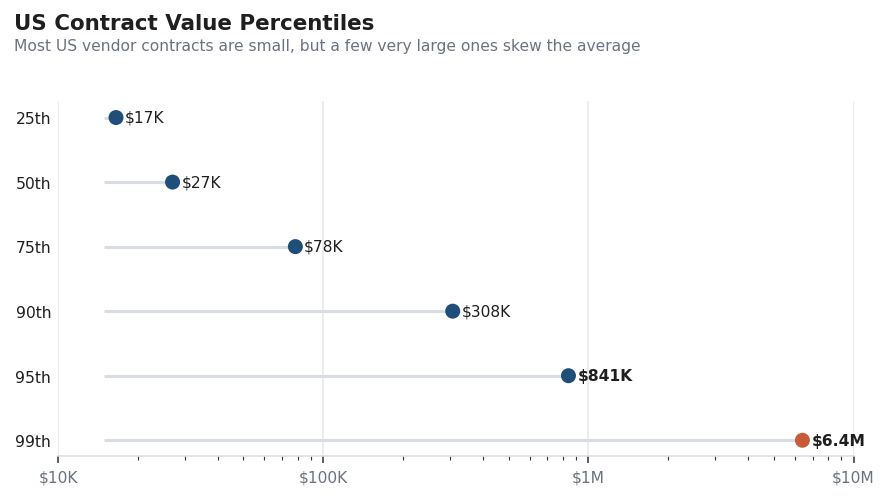

In [122]:
print("\n=== US Contract Value Percentiles ===\n")

labels = ["25th", "50th", "75th", "90th", "95th", "99th"]
values = percentiles.values

plot_compact_percentiles(
    values,
    labels,
    title="US Contract Value Percentiles",
    subtitle="Most US vendor contracts are small, but a few very large ones skew the average",
    figsize=(7, 4)   # <-- tweak per chart
)


=== US Contract Value Distribution (Clean Title Layout) ===



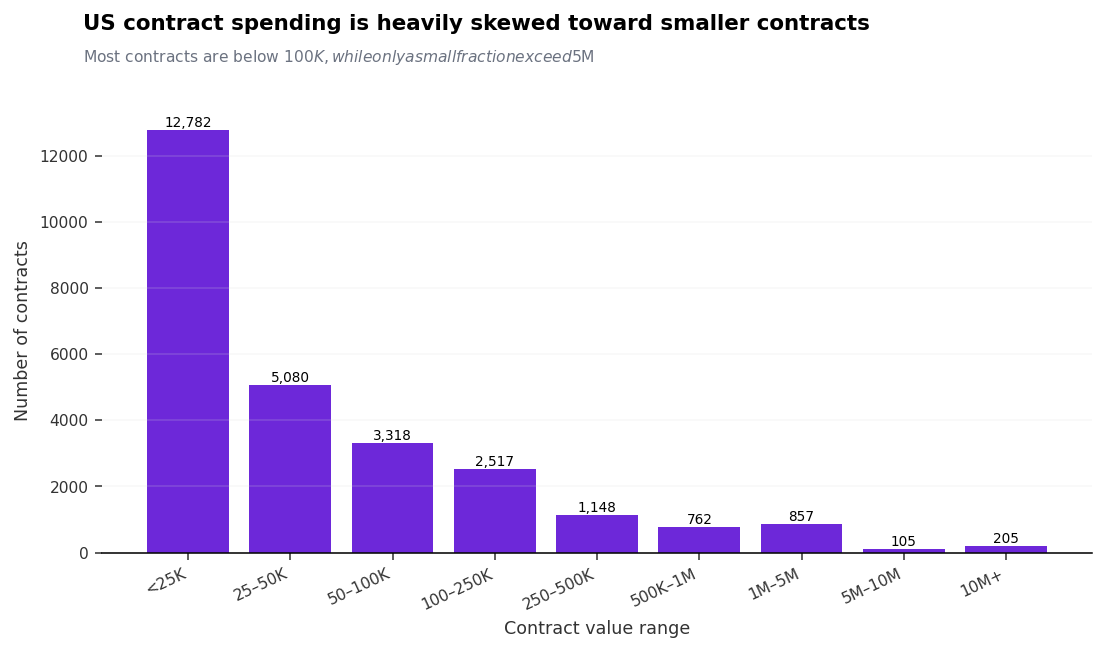

In [123]:
print("\n=== US Contract Value Distribution (Clean Title Layout) ===\n")

fig, ax = plt.subplots(figsize=(8, 4.8))

# --- Bars ---
bars = ax.bar(counts.index.astype(str), counts.values, color="#6D28D9")

# --- Clean axes ---
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)

ax.set_ylabel("Number of contracts", fontsize=9)
ax.set_xlabel("Contract value range", fontsize=9)

# --- Tick font control ---
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# --- Value labels ---
for bar, v in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v,
        f"{v:,}",
        ha='center',
        va='bottom',
        fontsize=7
    )

# --- Title ---
fig.text(
    0.08, 0.96,
    "US contract spending is heavily skewed toward smaller contracts",
    ha="left",
    va="top",
    fontsize=11,
    weight="bold"
)

# --- Subtitle ---
fig.text(
    0.08, 0.91,
    "Most contracts are below $100K, while only a small fraction exceed $5M",
    ha="left",
    va="top",
    fontsize=8,
    color="#6b7280"
)

# --- X label rotation ---
plt.xticks(rotation=25, ha='right')

# --- Layout ---
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

In [46]:
from IPython.display import display
print("\n=== Top Commodities ===\n")
df_us_clean["commodity"].value_counts().head(20)


=== Top Commodities ===



commodity
Good            13966
Service         12424
Construction      384
Name: count, dtype: int64


=== Top Commodities (% Share) ===



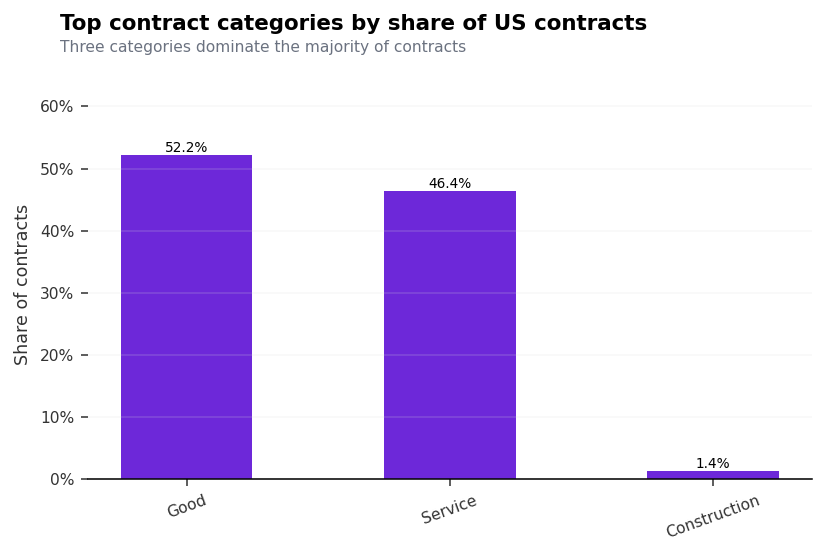

In [124]:
print("\n=== Top Commodities (% Share) ===\n")

pct = df_us_clean["commodity"].value_counts(normalize=True).head(10)

# Optional: shorten long labels
def shorten(x, max_len=18):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len] + "..."

labels = [shorten(v) for v in pct.index]

fig, ax = plt.subplots(figsize=(6, 4))

# Bars
bars = ax.bar(labels, pct.values, color="#6D28D9", width=0.5)

# Clean axes
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)

# Axis labels
ax.set_ylabel("Share of contracts", fontsize=9)

# Tick control
ax.tick_params(axis='x', labelsize=8, labelrotation=20)
ax.tick_params(axis='y', labelsize=8)

# Y-axis formatting
ax.set_ylim(0, pct.max() * 1.2)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

# Value labels
for b, v in zip(bars, pct.values):
    ax.text(
        b.get_x() + b.get_width()/2,
        v,
        f"{v:.1%}",
        ha='center',
        va='bottom',
        fontsize=7
    )

# Titles
fig.text(
    0.08, 0.95,
    "Top contract categories by share of US contracts",
    fontsize=11,
    weight="bold"
)

fig.text(
    0.08, 0.91,
    "Three categories dominate the majority of contracts",
    fontsize=8,
    color="#6b7280"
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

In [55]:
print("\n=== Agreement Types ===\n")
df_us_clean["agreement_type"].value_counts()


=== Agreement Types ===



agreement_type
-                                                                                                15262
NAFTA / CFTA                                                                                       712
(discontinued) NAFTA / CCFTA / CCoFTA / CHFTA / CPaFTA                                             433
WTO-AGP / NAFTA / CFTA / CCFTA / CCoFTA / CHFTA / CPaFTA / CPFTA / CKFTA                           337
CFTA                                                                                               240
NAFTA / CFTA / CCFTA / CCoFTA / CHFTA / CPaFTA / CKFTA                                              97
NAFTA / CFTA / CCFTA / CCoFTA / CHFTA / CPaFTA / CPFTA / CKFTA                                      63
CETA / TCA / WTO-AGP / NAFTA / CFTA / CCFTA / CCoFTA / CHFTA / CPaFTA / CPFTA / CKFTA               62
WTO-AGP / CFTA / CCFTA / CCoFTA / CHFTA / CPaFTA / CPFTA / CKFTA                                    48
CFTA / CCFTA / CCoFTA / CHFTA / CPaFTA / CPFTA / CKFTA    

In [56]:
print("\n=== Instrument Types ===\n")
df_us_clean["instrument_type"].value_counts()


=== Instrument Types ===



instrument_type
Contract                                       21330
Amendment                                       3492
Standing Offer/Supply Arrangement Agreement     1750
-                                                202
Name: count, dtype: int64


=== Contract Category Mix by Value Band (Readable) ===



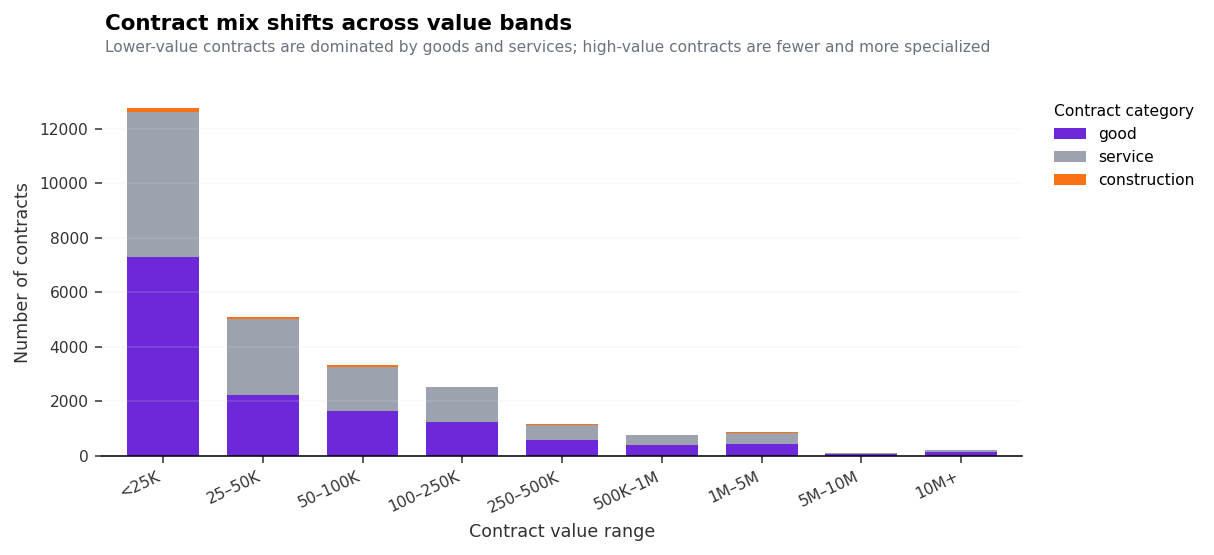

In [126]:
print("\n=== Contract Category Mix by Value Band (Readable) ===\n")

fig, ax = plt.subplots(figsize=(10, 4))

# Strong contrast palette
colors = {
    "good": "#6D28D9",        # primary purple
    "service": "#9CA3AF",     # neutral gray
    "construction": "#F97316" # accent orange
}

pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[colors.get(c, "#D1D5DB") for c in pivot.columns],
    width=0.72
)

# Clean styling
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)

ax.set_xlabel("Contract value range", fontsize=9)
ax.set_ylabel("Number of contracts", fontsize=9)
ax.set_title("")

# Tick font control
ax.tick_params(axis='x', labelsize=8, labelrotation=25)
ax.tick_params(axis='y', labelsize=8)

# Make x tick alignment explicit
for label in ax.get_xticklabels():
    label.set_ha('right')

# Titles
fig.text(
    0.08, 0.95,
    "Contract mix shifts across value bands",
    fontsize=11,
    weight="bold"
)

fig.text(
    0.08, 0.91,
    "Lower-value contracts are dominated by goods and services; high-value contracts are fewer and more specialized",
    fontsize=8,
    color="#6b7280"
)

# Legend
legend = ax.legend(
    title="Contract category",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=8
)

plt.tight_layout(rect=[0, 0, 0.88, 0.88])
plt.show()


=== Agreement Coverage (Individual Agreements) ===



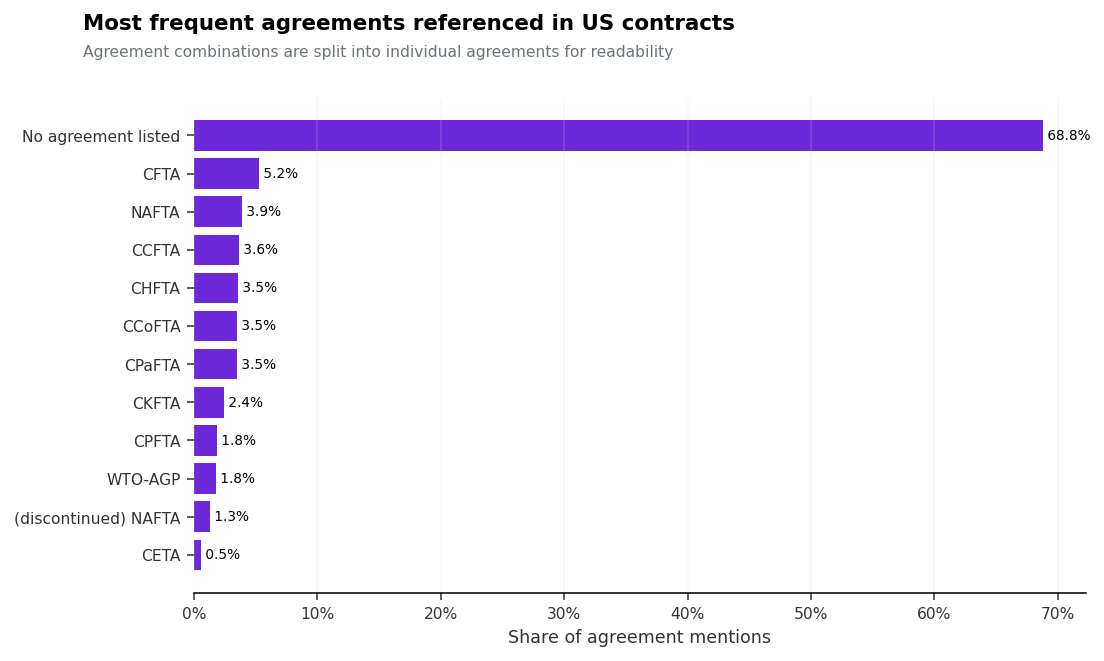

In [127]:
print("\n=== Agreement Coverage (Individual Agreements) ===\n")

import pandas as pd
import matplotlib.pyplot as plt

agreement_parts = (
    df_us_clean["agreement_type"]
    .fillna("No agreement listed")
    .replace("-", "No agreement listed")
    .str.split("/")
    .explode()
    .str.strip()
)

agreement_counts = agreement_parts.value_counts().head(12)
agreement_pct = agreement_counts / agreement_counts.sum()

# Reverse once for display
agreement_pct = agreement_pct[::-1]

# Optional: shorten long labels
def shorten(x, max_len=28):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len] + "..."

labels = [shorten(v) for v in agreement_pct.index]

fig, ax = plt.subplots(figsize=(8, 4.8))

# Bars
bars = ax.barh(labels, agreement_pct.values, color="#6D28D9")

# Clean styling
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.2)

# Axis labels
ax.set_xlabel("Share of agreement mentions", fontsize=9)
ax.set_ylabel("")

# Tick control
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)

# Percent formatting
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

# Value labels
for b, v in zip(bars, agreement_pct.values):
    ax.text(
        v,
        b.get_y() + b.get_height() / 2,
        f" {v:.1%}",
        va="center",
        fontsize=7
    )

# Titles
fig.text(
    0.08, 0.95,
    "Most frequent agreements referenced in US contracts",
    fontsize=11,
    weight="bold"
)

fig.text(
    0.08, 0.91,
    "Agreement combinations are split into individual agreements for readability",
    fontsize=8,
    color="#6b7280"
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()


=== US Contracts Over Time ===



/var/folders/2_/v9nzhgd118s4dqpsthz07ltc0000gp/T/ipykernel_12471/2706941123.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


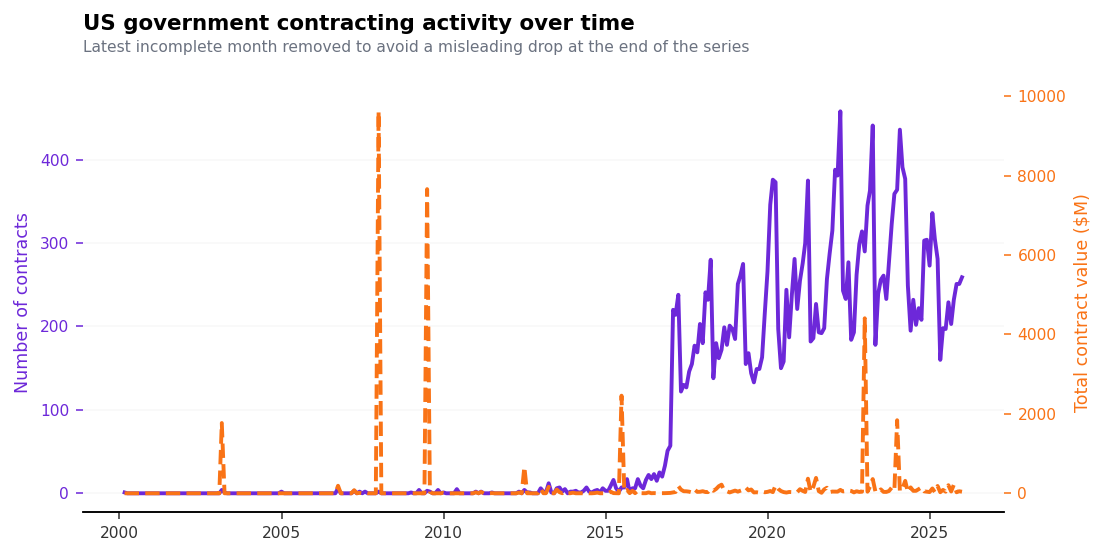

In [129]:
print("\n=== US Contracts Over Time ===\n")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_us_clean["contract_date"] = pd.to_datetime(df_us_clean["contract_date"], errors="coerce")

timeline = (
    df_us_clean
    .dropna(subset=["contract_date"])
    .set_index("contract_date")
    .resample("M")
    .agg(
        contract_count=("reference_number", "count"),
        total_value=("total_contract_value", "sum")
    )
    .reset_index()
)

# Remove incomplete latest month
last_month = timeline["contract_date"].max()
latest_source_date = df_us_clean["contract_date"].max()

if latest_source_date.month == last_month.month and latest_source_date.year == last_month.year:
    timeline = timeline.iloc[:-1]

fig, ax1 = plt.subplots(figsize=(8, 4))

COLOR_COUNT = "#6D28D9"
COLOR_VALUE = "#F97316"

# Left axis: contract count
ax1.plot(
    timeline["contract_date"],
    timeline["contract_count"],
    color=COLOR_COUNT,
    linewidth=2
)
ax1.set_ylabel("Number of contracts", color=COLOR_COUNT, fontsize=9)
ax1.tick_params(axis="y", colors=COLOR_COUNT, labelsize=8)

# Right axis: total value
ax2 = ax1.twinx()
ax2.plot(
    timeline["contract_date"],
    timeline["total_value"] / 1e6,
    color=COLOR_VALUE,
    linewidth=2,
    linestyle="--"
)
ax2.set_ylabel("Total contract value ($M)", color=COLOR_VALUE, fontsize=9)
ax2.tick_params(axis="y", colors=COLOR_VALUE, labelsize=8)

# X-axis every 5 years
ax1.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(axis="x", labelsize=8)

# Clean styling
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
ax1.grid(axis="y", alpha=0.2)

# Titles
fig.text(
    0.08, 0.95,
    "US government contracting activity over time",
    fontsize=11,
    weight="bold"
)

fig.text(
    0.08, 0.91,
    "Latest incomplete month removed to avoid a misleading drop at the end of the series",
    fontsize=8,
    color="#6b7280"
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

In [74]:
print("\n=== Filter Service Contracts (2023–2026) and Export CSV ===\n")

import pandas as pd

# Ensure date is parsed
df_us_clean["contract_date"] = pd.to_datetime(df_us_clean["contract_date"], errors="coerce")

# Normalize service category
df_us_clean["commodity_clean"] = (
    df_us_clean["commodity"]
    .fillna("")
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.strip()
)

# Filter: 2023-01-01 through 2026-12-31, services only
df_us_services_2023_2026 = df_us_clean[
    (df_us_clean["contract_date"] >= "2023-01-01") &
    (df_us_clean["contract_date"] <= "2026-12-31") &
    (df_us_clean["commodity_clean"] == "service")
    ].copy()

print(f"Rows: {len(df_us_services_2023_2026):,}")
print(
    f"Date range: "
    f"{df_us_services_2023_2026['contract_date'].min()} to "
    f"{df_us_services_2023_2026['contract_date'].max()}"
)

# output_path = "data/us_services_contracts_2023_2026.csv"
# df_us_services_2023_2026.to_csv(output_path, index=False)

# print(f"Saved: {output_path}")


=== Filter Service Contracts (2023–2026) and Export CSV ===

Rows: 4,892
Date range: 2023-01-01 00:00:00+00:00 to 2026-01-08 00:00:00+00:00
Saved: data/us_services_contracts_2023_2026.csv


In [75]:
df_us_services_2023_2026.head(10)

,reference_number,procurement_identification_number,vendor_name,vendor_postal_code,buyer_name,contract_date,contract_year,economic_object_code,description_of_work_english,contract_period_start_date,...,procurement_strategy_for_indigenous_business,original_contract_value.1,amendment_value,award_criteria,standing_offer,comprehensive_land_claims_agreement,id,value_band,contract_category,commodity_clean
13241,C-2022-2023-Q4-00087,3000757686,RANE NETWORK INC,NaN,"McNeil, Connor",2023-01-04 00:00:00+00:00,2023,583,License/Maintenance fees for application softw...,2023-01-04T00:00:00Z,...,1. None,-,-,Not applicable,Contract awarded by the department.,Not Applicable,"aafc-aac,C-2022-2023-Q4-00087",<25K,service,service
13288,C-2022-2023-Q4-00134,3000753913,WORLD TRADE ONLINE,NaN,"Hurley, Gerry",2023-03-01 00:00:00+00:00,2023,361,Electronic subscriptions and electronic public...,2023-03-01T00:00:00Z,...,1. None,-,-,Not applicable,Contract awarded by the department.,Not Applicable,"aafc-aac,C-2022-2023-Q4-00134",<25K,service,service
13289,C-2022-2023-Q4-00135,20230559A,AMERICAN PHYTOPATHOLOGICAL SOCIETY,NaN,"Durand-Marsh, Gabrielle",2023-01-01 00:00:00+00:00,2023,361,Electronic subscriptions and electronic public...,2023-01-01T00:00:00Z,...,1. None,-,-,Not applicable,Contract awarded by PSPC on behalf of the clie...,Not Applicable,"aafc-aac,C-2022-2023-Q4-00135",25–50K,service,service
13294,C-2022-2023-Q4-00140,3000751435,TEKLYNX AMERICAS INC,NaN,"Hurley, Gerry",2023-01-15 00:00:00+00:00,2023,583,License/Maintenance fees for application softw...,2023-01-15T00:00:00Z,...,1. None,-,-,Not applicable,Contract awarded by the department.,Not Applicable,"aafc-aac,C-2022-2023-Q4-00140",<25K,service,service
13317,C-2022-2023-Q4-00163,3000760528,SONOROUS TECHNOLOGIES CORPORATION,NaN,"O'Neill, Natalie",2023-02-15 00:00:00+00:00,2023,431,Scientific consultants,2023-02-15T00:00:00Z,...,1. None,-,-,Not applicable,Contract awarded by the department.,Not Applicable,"aafc-aac,C-2022-2023-Q4-00163",25–50K,service,service
13325,C-2022-2023-Q4-00171,3000757796,COVARIANCE BIOSCIENCES DBA AGRIPLEX,NaN,"Fulawka, Vickie",2023-01-06 00:00:00+00:00,2023,430,Scientific services,2023-01-06T00:00:00Z,...,1. None,-,-,Not applicable,Contract awarded by the department.,Not Applicable,"aafc-aac,C-2022-2023-Q4-00171",<25K,service,service
13341,C-2022-2023-Q4-00187,3000760212,DATACAMP INC,NaN,"Young, Mitchell",2023-03-01 00:00:00+00:00,2023,448,Purchase of training packages and courses,2023-03-01T00:00:00Z,...,1. None,-,-,Not applicable,Contract awarded by the department.,Not Applicable,"aafc-aac,C-2022-2023-Q4-00187",<25K,service,service
13392,C-2022-2023-Q4-00240,3000758107,AGVISE LABORATORIES INC,NaN,"Cullen, Melody",2023-01-11 00:00:00+00:00,2023,430,Scientific services,2023-01-11T00:00:00Z,...,1. None,-,-,Lowest Price,Contract awarded by the department.,Not Applicable,"aafc-aac,C-2022-2023-Q4-00240",50–100K,service,service
13393,C-2022-2023-Q4-00241,3000758107,AGVISE LABORATORIES INC,NaN,NaN,2023-01-11 00:00:00+00:00,2023,430,Scientific services,2023-01-11T00:00:00Z,...,1. None,-,-,Not applicable,Contract awarded by the department.,Not Applicable,"aafc-aac,C-2022-2023-Q4-00241",25–50K,service,service
13400,C-2022-2023-Q4-00248,3000758319,GAMS DEVELOPMENT CORPORATION,NaN,"El-Merhi, Jamal",2023-01-16 00:00:00+00:00,2023,583,License/Maintenance fees for application softw...,2023-01-16T00:00:00Z,...,1. None,-,-,Not applicable,Contract awarded by the department.,Not Applicable,"aafc-aac,C-2022-2023-Q4-00248",<25K,service,service


/var/folders/2_/v9nzhgd118s4dqpsthz07ltc0000gp/T/ipykernel_12471/1744634413.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([shorten(v) for v in org_summary.index])


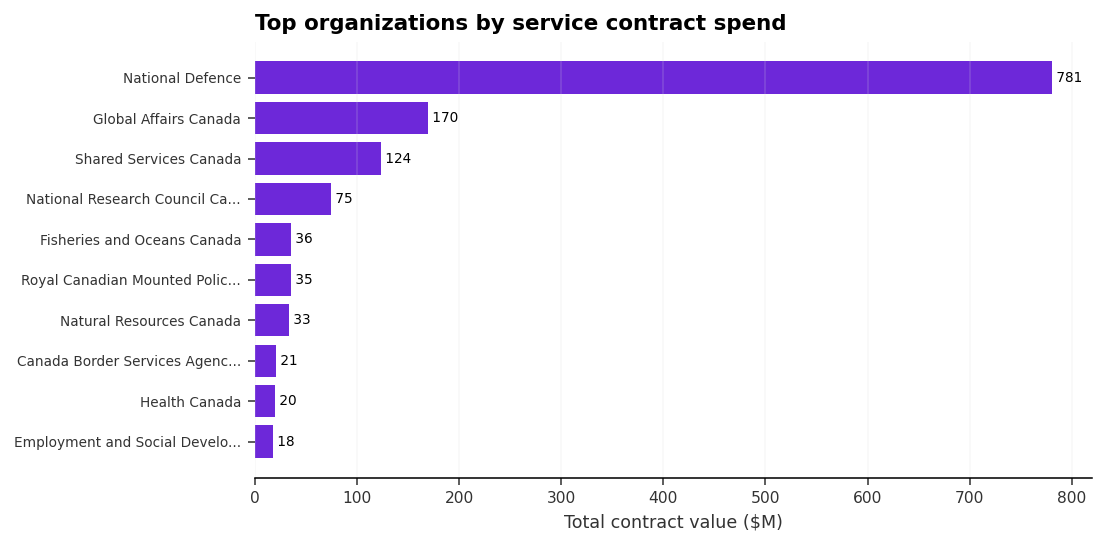

In [119]:
# --- Top organizations by SERVICES spend (refactored for consistency) ---

org_summary = (
    df_us_services_2023_2026
    .groupby("organization")
    .agg(
        contracts=("reference_number", "count"),
        total_value=("total_contract_value", "sum")
    )
    .sort_values("total_value", ascending=False)
    .head(10)
)

# Reverse for horizontal bar display
org_summary = org_summary[::-1]

fig, ax = plt.subplots(figsize=(8, 4))  # ✅ consistent sizing

# Bars
ax.barh(
    org_summary.index,
    org_summary["total_value"] / 1e6,
    color="#6D28D9"
)

# Labels & title
ax.set_xlabel("Total contract value ($M)", fontsize=9)
ax.set_title(
    "Top organizations by service contract spend",
    loc="left",
    fontsize=11,
    weight="bold"
)

# Clean styling
ax.grid(axis="x", alpha=0.2)
ax.spines[['top','right']].set_visible(False)

# --- Font control (consistent across all charts) ---
ax.tick_params(axis='y', labelsize=7)
ax.tick_params(axis='x', labelsize=8)

# Optional: shorten long organization names
def shorten(x, max_len=28):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len] + "..."

ax.set_yticklabels([shorten(v) for v in org_summary.index])

# Annotate values
for i, v in enumerate(org_summary["total_value"] / 1e6):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=7)

plt.tight_layout()
plt.show()

In [91]:
import unicodedata

def clean_text(x):
    return unicodedata.normalize("NFKD", str(x)).encode("ascii", "ignore").decode("ascii")

df_us_services_2023_2026["vendor_name"] = df_us_services_2023_2026["vendor_name"].apply(clean_text)


=== Vendor Concentration (Pareto View) ===



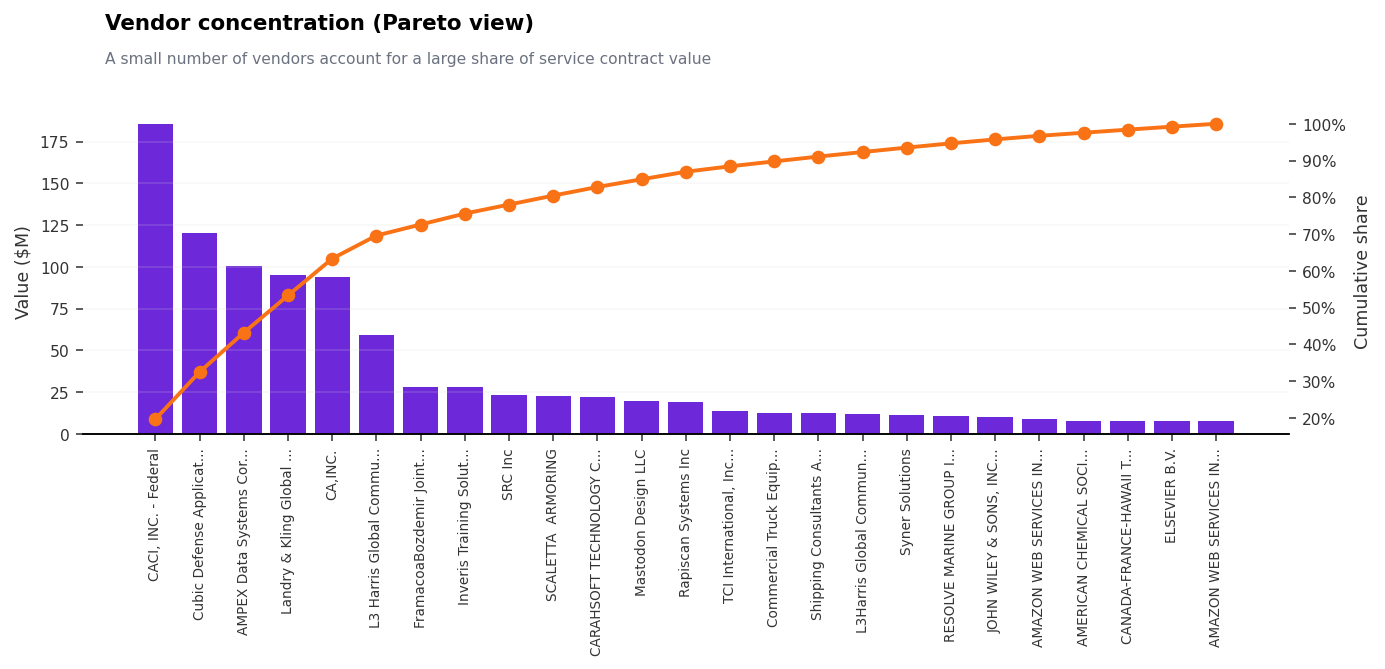

In [136]:
print("\n=== Vendor Concentration (Pareto View) ===\n")

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

vendor = (
    df_us_services_2023_2026
    .groupby("vendor_name")["total_contract_value"]
    .sum()
    .sort_values(ascending=False)
)

top = vendor.head(25)
cum_pct = top.cumsum() / top.sum()

# Numeric x positions
x = range(len(top))

# Optional: shorten labels
def shorten(x, max_len=22):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len] + "..."

labels = [shorten(v) for v in top.index]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bars
ax1.bar(x, top.values / 1e6, color="#6D28D9")
ax1.set_ylabel("Value ($M)", fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis="y", alpha=0.2)

# X-axis labels
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=90, ha="center", fontsize=7)
ax1.tick_params(axis='y', labelsize=8)

# Pareto line
ax2 = ax1.twinx()
ax2.plot(x, cum_pct, color="#F97316", marker="o", linewidth=2)
ax2.set_ylabel("Cumulative share", fontsize=9)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.tick_params(axis='y', labelsize=8)
ax2.spines[['top']].set_visible(False)

# Titles
fig.text(
    0.08, 0.95,
    "Vendor concentration (Pareto view)",
    fontsize=11,
    weight="bold"
)

fig.text(
    0.08, 0.91,
    "A small number of vendors account for a large share of service contract value",
    fontsize=8,
    color="#6b7280"
)

plt.tight_layout(rect=[0, 0.18, 1, 0.88])

# --- ✅ EXPORT ---
plt.savefig(
    "vendor_concentration_pareto.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


=== Vendor Concentration for Goods (Pareto View) ===



/var/folders/2_/v9nzhgd118s4dqpsthz07ltc0000gp/T/ipykernel_12471/186971153.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.18, 1, 0.88])


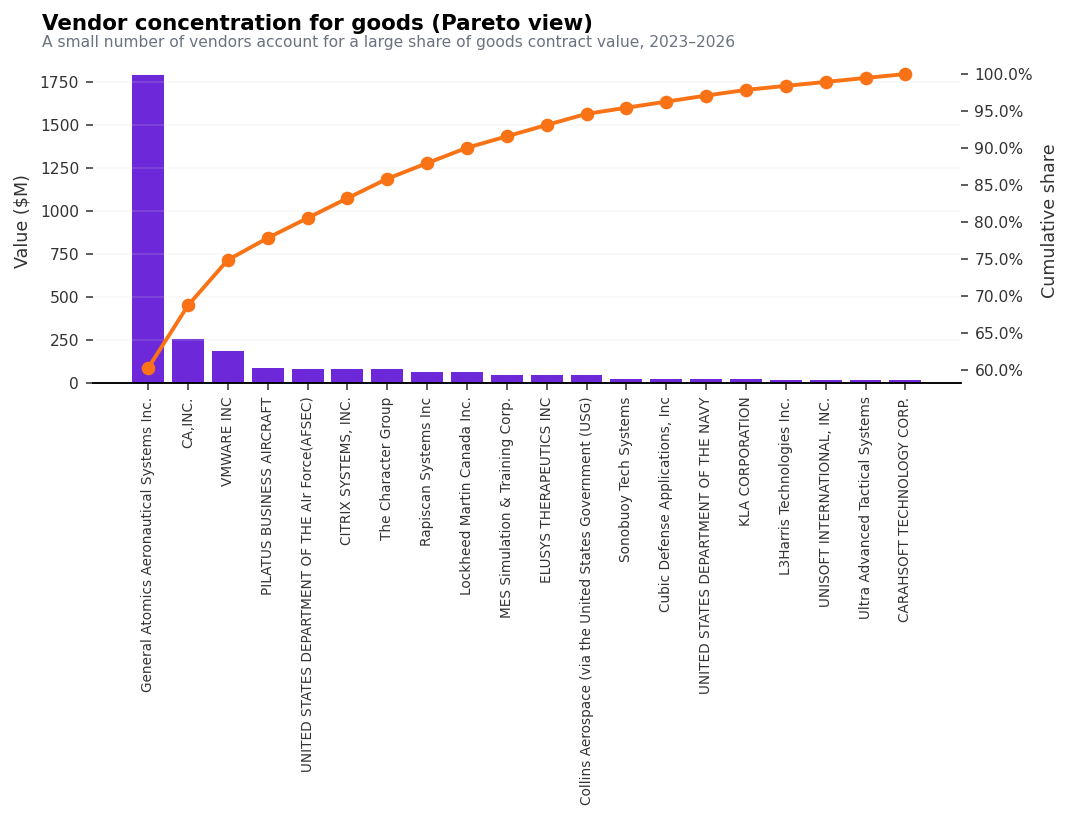

In [139]:
print("\n=== Vendor Concentration for Goods (Pareto View) ===\n")

# Filter goods, 2023–2026
df_us_goods_2023_2026 = df_us_clean[
    (df_us_clean["contract_date"] >= "2023-01-01") &
    (df_us_clean["contract_date"] <= "2026-12-31") &
    (df_us_clean["commodity_clean"] == "good")
    ].copy()

# Export to data
# output_path = "data/us_goods_contracts_2023_2026.csv"
# df_us_goods_2023_2026.to_csv(output_path, index=False)
#
# print(f"Saved: {output_path}")

vendor = (
    df_us_goods_2023_2026
    .groupby("vendor_name")["total_contract_value"]
    .sum()
    .sort_values(ascending=False)
)

top = vendor.head(20)
cum_pct = top.cumsum() / top.sum()

# Numeric x positions
x = range(len(top))

fig, ax1 = plt.subplots(figsize=(8, 3))

# Bars
ax1.bar(x, top.values / 1e6, color="#6D28D9")
ax1.set_ylabel("Value ($M)", fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis="y", alpha=0.2)

# --- Font control (key section) ---
ax1.set_xticks(list(x))
ax1.set_xticklabels(top.index, rotation=90, ha="center", fontsize=7)
ax1.tick_params(axis='y', labelsize=8)

# Pareto line
ax2 = ax1.twinx()
ax2.plot(x, cum_pct, color="#F97316", marker="o", linewidth=2)
ax2.set_ylabel("Cumulative share", fontsize=9)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.tick_params(axis='y', labelsize=8)
ax2.spines[['top']].set_visible(False)

# Titles
fig.text(
    0.08, 0.95,
    "Vendor concentration for goods (Pareto view)",
    fontsize=11, weight="bold"
)

fig.text(
    0.08, 0.91,
    "A small number of vendors account for a large share of goods contract value, 2023–2026",
    fontsize=8, color="#6b7280"
)

plt.tight_layout(rect=[0, 0.18, 1, 0.88])
plt.show()

/var/folders/2_/v9nzhgd118s4dqpsthz07ltc0000gp/T/ipykernel_12471/3836064344.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([shorten(v) for v in org_summary.index])


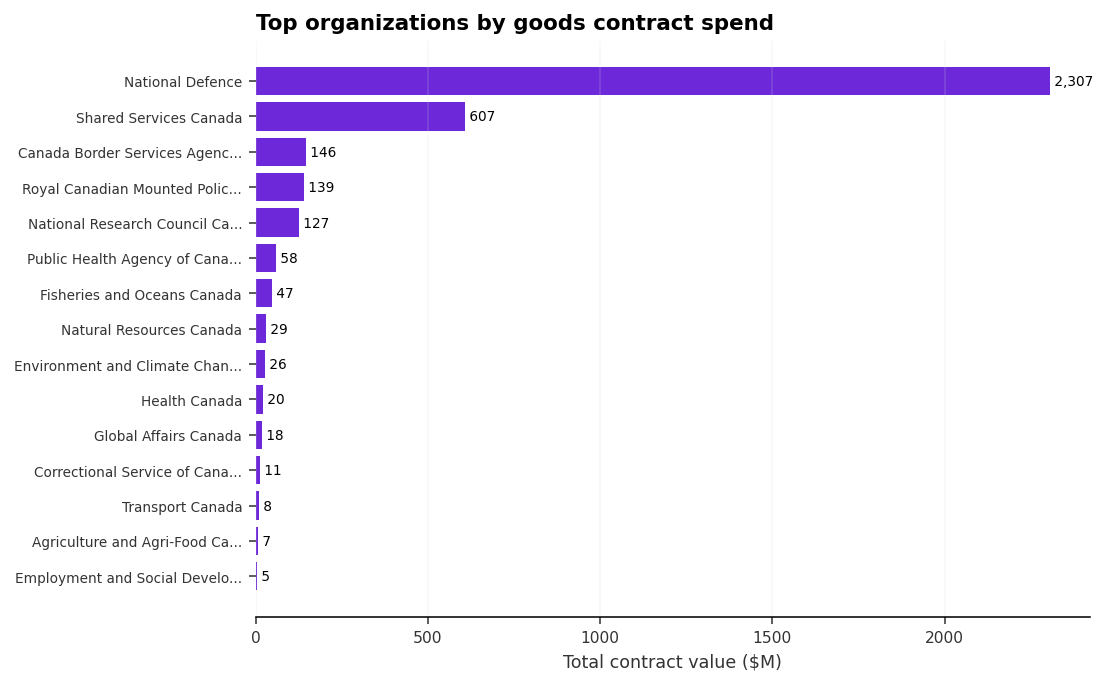

In [117]:
# --- Top organizations by GOODS spend (refactored for font control) ---

org_summary = (
    df_us_goods_2023_2026
    .groupby("organization")
    .agg(
        contracts=("reference_number", "count"),
        total_value=("total_contract_value", "sum")
    )
    .sort_values("total_value", ascending=False)
    .head(15)
)

# Reverse for horizontal bar display
org_summary = org_summary[::-1]

fig, ax = plt.subplots(figsize=(8, 5))

# Bars
ax.barh(
    org_summary.index,
    org_summary["total_value"] / 1e6,
    color="#6D28D9"
)

# Labels & title
ax.set_xlabel("Total contract value ($M)", fontsize=9)
ax.set_title(
    "Top organizations by goods contract spend",
    loc="left",
    fontsize=11,
    weight="bold"
)

# Clean styling
ax.grid(axis="x", alpha=0.2)
ax.spines[['top','right']].set_visible(False)

# --- Font control (consistent with vendor chart) ---
ax.tick_params(axis='y', labelsize=7)   # ✅ reduced y-axis font
ax.tick_params(axis='x', labelsize=8)

# Optional: shorten long organization names
def shorten(x, max_len=28):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len] + "..."

ax.set_yticklabels([shorten(v) for v in org_summary.index])

# Annotate values
for i, v in enumerate(org_summary["total_value"] / 1e6):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=7)

plt.tight_layout()
plt.show()

/var/folders/2_/v9nzhgd118s4dqpsthz07ltc0000gp/T/ipykernel_12471/569565410.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([shorten(v) for v in vendor_summary.index])


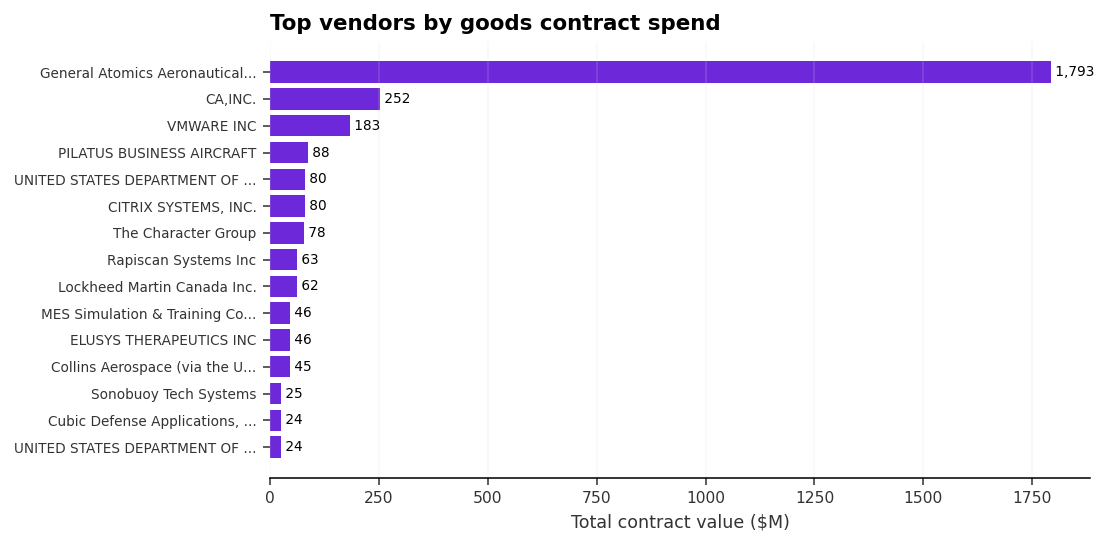

In [116]:
# --- Top vendors by GOODS spend (refactored for font control) ---

vendor_summary = (
    df_us_goods_2023_2026
    .groupby("vendor_name")
    .agg(
        contracts=("reference_number", "count"),
        total_value=("total_contract_value", "sum")
    )
    .sort_values("total_value", ascending=False)
    .head(15)
)

# Reverse for horizontal bar display
vendor_summary = vendor_summary[::-1]

fig, ax = plt.subplots(figsize=(8, 4))

# Bars
ax.barh(
    vendor_summary.index,
    vendor_summary["total_value"] / 1e6,
    color="#6D28D9"
)

# Labels & title
ax.set_xlabel("Total contract value ($M)", fontsize=9)
ax.set_title(
    "Top vendors by goods contract spend",
    loc="left",
    fontsize=11,
    weight="bold"
)

# Clean styling
ax.grid(axis="x", alpha=0.2)
ax.spines[['top','right']].set_visible(False)

# --- Font control (this is the key part) ---
ax.tick_params(axis='y', labelsize=7)   # ✅ reduce y-axis label font
ax.tick_params(axis='x', labelsize=8)

# Shorten long vendor names
def shorten(x, max_len=28):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len] + "..."

ax.set_yticklabels([shorten(v) for v in vendor_summary.index])

# Annotate values
for i, v in enumerate(vendor_summary["total_value"] / 1e6):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=7)

plt.tight_layout()
plt.show()